# Preprocessing Unifié — FD001 + FD002 + FD003 + FD004
## 17 features pour tous — Normalisation par condition

| Dataset | Conditions | Pannes | Normalisation |
|---------|-----------|--------|---------------|
| FD001 | 1 | 1 | Globale (1 condition) |
| FD002 | 6 | 1 | Par condition (KMeans) |
| FD003 | 1 | 2 | Globale (1 condition) |
| FD004 | 6 | 2 | Par condition (KMeans) |

**Sortie :** `X_train_combined.npy`, `y_train_combined.npy` + 4 test sets séparés

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, os, joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
print(' Imports OK')

 Imports OK


In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR    = '/content/drive/MyDrive/industrial-ai-platform'
DATA_DIR    = f'{BASE_DIR}/Data/cmapss'
CONFIG_PATH = f'{BASE_DIR}/feature_config.json'
OUTPUT_DIR  = f'{BASE_DIR}/preprocessing_combined'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Charger feature config FD001
with open(CONFIG_PATH) as f:
    config = json.load(f)

SENSORS_TO_KEEP = config['sensors_to_keep']  # 14 capteurs
SENSORS_TO_DROP = config['sensors_to_drop']
RUL_CAP         = config['rul_cap']           # 125
WINDOW_SIZE     = 30
SETTING_COLS    = ['op_setting_1', 'op_setting_2', 'op_setting_3']
FEATURE_COLS    = SENSORS_TO_KEEP + SETTING_COLS  # 17 features pour tous
N_FEATURES      = len(FEATURE_COLS)               # 17

COLUMNS = [
    'unit_id', 'time_cycle',
    'op_setting_1', 'op_setting_2', 'op_setting_3',
    *[f'sensor_{i:02d}' for i in range(1, 22)]
]

print(f'Features    : {N_FEATURES} (14 capteurs + 3 settings)')
print(f'Window size : {WINDOW_SIZE}')
print(f'RUL cap     : {RUL_CAP}')
print(f'Output dir  : {OUTPUT_DIR}')

Mounted at /content/drive
Features    : 17 (14 capteurs + 3 settings)
Window size : 30
RUL cap     : 125
Output dir  : /content/drive/MyDrive/industrial-ai-platform/preprocessing_combined


## 2. Fonctions communes

In [3]:
def load_dataset(name):
    """Charger train, test, RUL."""
    df_train = pd.read_csv(f'{DATA_DIR}/train_{name}.txt',
                           sep=r'\s+', header=None, names=COLUMNS)
    df_test  = pd.read_csv(f'{DATA_DIR}/test_{name}.txt',
                           sep=r'\s+', header=None, names=COLUMNS)
    df_rul   = pd.read_csv(f'{DATA_DIR}/RUL_{name}.txt',
                           header=None, names=['RUL_true'])
    print(f'{name} → Train:{df_train.shape} | '
          f'Moteurs:{df_train["unit_id"].nunique()} | '
          f'Test moteurs:{df_test["unit_id"].nunique()}')
    return df_train, df_test, df_rul


def compute_rul(df_train, df_test, df_rul):
    """Calculer et plafonner RUL."""
    # Train
    max_cyc   = df_train.groupby('unit_id')['time_cycle'].max().rename('max_cycle')
    df_train  = df_train.merge(max_cyc, on='unit_id')
    df_train['RUL'] = (df_train['max_cycle'] - df_train['time_cycle']).clip(upper=RUL_CAP)

    # Test
    test_max  = df_test.groupby('unit_id')['time_cycle'].max().reset_index()
    test_max.columns = ['unit_id', 'max_cycle_test']
    df_test   = df_test.merge(test_max, on='unit_id')
    df_rul['unit_id'] = range(1, len(df_rul) + 1)
    df_test   = df_test.merge(df_rul, on='unit_id')
    df_test['RUL'] = (df_test['RUL_true'] +
                      df_test['max_cycle_test'] -
                      df_test['time_cycle']).clip(upper=RUL_CAP)
    return df_train, df_test


def drop_useless_cols(df_train, df_test):
    """Supprimer colonnes inutiles."""
    to_drop = SENSORS_TO_DROP + ['max_cycle', 'max_cycle_test', 'RUL_true']
    df_train = df_train.drop(columns=[c for c in to_drop if c in df_train.columns])
    df_test  = df_test.drop(columns=[c for c in to_drop if c in df_test.columns])
    return df_train, df_test


def normalize_by_condition(df_train, df_test, n_conditions):
    """
    Normalisation par condition opérationnelle.
    - n_conditions=1 → scaler global (FD001, FD003)
    - n_conditions=6 → KMeans + scaler par cluster (FD002, FD004)
    """
    df_train = df_train.copy()
    df_test  = df_test.copy()
    sensors_only = SENSORS_TO_KEEP  # normaliser seulement les capteurs

    if n_conditions == 1:
        # Scaler global
        scaler = MinMaxScaler(feature_range=(0, 1))
        df_train[sensors_only] = scaler.fit_transform(df_train[sensors_only])
        df_test[sensors_only]  = scaler.transform(df_test[sensors_only])
        kmeans  = None
        scalers = {0: scaler}
        print(f'  → Scaler global appliqué (1 condition)')
    else:
        # KMeans + scaler par cluster
        kmeans = KMeans(n_clusters=n_conditions, random_state=42, n_init=10)
        df_train['condition'] = kmeans.fit_predict(df_train[SETTING_COLS])
        df_test['condition']  = kmeans.predict(df_test[SETTING_COLS])
        scalers = {}
        for cond in range(n_conditions):
            mask_tr = df_train['condition'] == cond
            mask_te = df_test['condition']  == cond
            scaler  = MinMaxScaler(feature_range=(0, 1))
            df_train.loc[mask_tr, sensors_only] = scaler.fit_transform(
                df_train.loc[mask_tr, sensors_only]
            )
            if mask_te.sum() > 0:
                df_test.loc[mask_te, sensors_only] = scaler.transform(
                    df_test.loc[mask_te, sensors_only]
                )
            scalers[cond] = scaler
        df_train = df_train.drop(columns=['condition'])
        df_test  = df_test.drop(columns=['condition'])
        print(f'  → Normalisation par condition ({n_conditions} clusters)')

    # Normaliser les settings entre 0 et 1 (globalement)
    setting_scaler = MinMaxScaler(feature_range=(0, 1))
    df_train[SETTING_COLS] = setting_scaler.fit_transform(df_train[SETTING_COLS])
    df_test[SETTING_COLS]  = setting_scaler.transform(df_test[SETTING_COLS])

    return df_train, df_test, kmeans, scalers, setting_scaler


def create_sequences(df, window_size=30):
    X_list, y_list = [], []
    for _, group in df.groupby('unit_id'):
        data   = group[FEATURE_COLS].values
        labels = group['RUL'].values
        T = len(data)
        if T < window_size:
            pad    = np.repeat(data[[0]], window_size - T, axis=0)
            data   = np.vstack([pad, data])
            labels = np.concatenate([np.repeat(labels[0], window_size - T), labels])
            T = window_size
        for t in range(T - window_size + 1):
            X_list.append(data[t:t+window_size])
            y_list.append(labels[t+window_size-1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def create_test_sequences(df, window_size=30):
    X_list, y_list = [], []
    for _, group in df.groupby('unit_id'):
        data   = group[FEATURE_COLS].values
        labels = group['RUL'].values
        T = len(data)
        if T < window_size:
            pad    = np.repeat(data[[0]], window_size - T, axis=0)
            data   = np.vstack([pad, data])
            labels = np.concatenate([np.repeat(labels[0], window_size - T), labels])
        X_list.append(data[-window_size:])
        y_list.append(labels[-1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def get_unit_ids(df, window_size=30):
    """Construire unit_ids_per_seq."""
    max_cycles = df.groupby('unit_id')['time_cycle'].max()
    ids = []
    for uid, cnt in max_cycles.items():
        ids.extend([uid] * max(cnt - window_size + 1, 1))
    return np.array(ids)


print(' Toutes les fonctions définies')

 Toutes les fonctions définies


## 3. Preprocessing FD001 (17 features)

In [4]:
print('=' * 50)
print(' FD001 — 1 condition, 1 panne')
print('=' * 50)

df_train_fd001, df_test_fd001, df_rul_fd001 = load_dataset('FD001')
df_train_fd001, df_test_fd001 = compute_rul(df_train_fd001, df_test_fd001, df_rul_fd001)
df_train_fd001, df_test_fd001 = drop_useless_cols(df_train_fd001, df_test_fd001)

df_train_fd001, df_test_fd001, km1, sc1, ss1 = normalize_by_condition(
    df_train_fd001, df_test_fd001, n_conditions=1
)

X_train_fd001, y_train_fd001 = create_sequences(df_train_fd001)
X_test_fd001,  y_test_fd001  = create_test_sequences(df_test_fd001)
unit_ids_fd001 = get_unit_ids(df_train_fd001)

# Sauvegarder test set séparé
np.save(f'{OUTPUT_DIR}/X_test_fd001.npy', X_test_fd001)
np.save(f'{OUTPUT_DIR}/y_test_fd001.npy', y_test_fd001)
joblib.dump(sc1, f'{OUTPUT_DIR}/scalers_fd001.pkl')

print(f'X_train : {X_train_fd001.shape}')
print(f'X_test  : {X_test_fd001.shape}')
print(' FD001 terminé')

 FD001 — 1 condition, 1 panne
FD001 → Train:(20631, 26) | Moteurs:100 | Test moteurs:100
  → Scaler global appliqué (1 condition)
X_train : (17731, 30, 17)
X_test  : (100, 30, 17)
 FD001 terminé


## 4. Preprocessing FD002 (17 features, 6 conditions)

In [5]:
print('=' * 50)
print(' FD002 — 6 conditions, 1 panne')
print('=' * 50)

df_train_fd002, df_test_fd002, df_rul_fd002 = load_dataset('FD002')
df_train_fd002, df_test_fd002 = compute_rul(df_train_fd002, df_test_fd002, df_rul_fd002)
df_train_fd002, df_test_fd002 = drop_useless_cols(df_train_fd002, df_test_fd002)

df_train_fd002, df_test_fd002, km2, sc2, ss2 = normalize_by_condition(
    df_train_fd002, df_test_fd002, n_conditions=6
)

X_train_fd002, y_train_fd002 = create_sequences(df_train_fd002)
X_test_fd002,  y_test_fd002  = create_test_sequences(df_test_fd002)
unit_ids_fd002 = get_unit_ids(df_train_fd002)

# Sauvegarder test set séparé
np.save(f'{OUTPUT_DIR}/X_test_fd002.npy', X_test_fd002)
np.save(f'{OUTPUT_DIR}/y_test_fd002.npy', y_test_fd002)
joblib.dump(km2, f'{OUTPUT_DIR}/kmeans_fd002.pkl')
joblib.dump(sc2, f'{OUTPUT_DIR}/scalers_fd002.pkl')

print(f'X_train : {X_train_fd002.shape}')
print(f'X_test  : {X_test_fd002.shape}')
print(' FD002 terminé')

 FD002 — 6 conditions, 1 panne
FD002 → Train:(53759, 26) | Moteurs:260 | Test moteurs:259
  → Normalisation par condition (6 clusters)
X_train : (46219, 30, 17)
X_test  : (259, 30, 17)
 FD002 terminé


## 5. Preprocessing FD003 (17 features)

In [6]:
print('=' * 50)
print(' FD003 — 1 condition, 2 pannes')
print('=' * 50)

df_train_fd003, df_test_fd003, df_rul_fd003 = load_dataset('FD003')
df_train_fd003, df_test_fd003 = compute_rul(df_train_fd003, df_test_fd003, df_rul_fd003)
df_train_fd003, df_test_fd003 = drop_useless_cols(df_train_fd003, df_test_fd003)

df_train_fd003, df_test_fd003, km3, sc3, ss3 = normalize_by_condition(
    df_train_fd003, df_test_fd003, n_conditions=1
)

X_train_fd003, y_train_fd003 = create_sequences(df_train_fd003)
X_test_fd003,  y_test_fd003  = create_test_sequences(df_test_fd003)
unit_ids_fd003 = get_unit_ids(df_train_fd003)

# Sauvegarder test set séparé
np.save(f'{OUTPUT_DIR}/X_test_fd003.npy', X_test_fd003)
np.save(f'{OUTPUT_DIR}/y_test_fd003.npy', y_test_fd003)
joblib.dump(sc3, f'{OUTPUT_DIR}/scalers_fd003.pkl')

print(f'X_train : {X_train_fd003.shape}')
print(f'X_test  : {X_test_fd003.shape}')
print(' FD003 terminé')

 FD003 — 1 condition, 2 pannes
FD003 → Train:(24720, 26) | Moteurs:100 | Test moteurs:100
  → Scaler global appliqué (1 condition)
X_train : (21820, 30, 17)
X_test  : (100, 30, 17)
 FD003 terminé


## 6. Preprocessing FD004 (17 features, 6 conditions)

In [7]:
print('=' * 50)
print(' FD004 — 6 conditions, 2 pannes')
print('=' * 50)

df_train_fd004, df_test_fd004, df_rul_fd004 = load_dataset('FD004')
df_train_fd004, df_test_fd004 = compute_rul(df_train_fd004, df_test_fd004, df_rul_fd004)
df_train_fd004, df_test_fd004 = drop_useless_cols(df_train_fd004, df_test_fd004)

df_train_fd004, df_test_fd004, km4, sc4, ss4 = normalize_by_condition(
    df_train_fd004, df_test_fd004, n_conditions=6
)

X_train_fd004, y_train_fd004 = create_sequences(df_train_fd004)
X_test_fd004,  y_test_fd004  = create_test_sequences(df_test_fd004)
unit_ids_fd004 = get_unit_ids(df_train_fd004)

# Sauvegarder test set séparé
np.save(f'{OUTPUT_DIR}/X_test_fd004.npy', X_test_fd004)
np.save(f'{OUTPUT_DIR}/y_test_fd004.npy', y_test_fd004)
joblib.dump(km4, f'{OUTPUT_DIR}/kmeans_fd004.pkl')
joblib.dump(sc4, f'{OUTPUT_DIR}/scalers_fd004.pkl')

print(f'X_train : {X_train_fd004.shape}')
print(f'X_test  : {X_test_fd004.shape}')
print(' FD004 terminé')

 FD004 — 6 conditions, 2 pannes
FD004 → Train:(61249, 26) | Moteurs:249 | Test moteurs:248
  → Normalisation par condition (6 clusters)
X_train : (54028, 30, 17)
X_test  : (248, 30, 17)
 FD004 terminé


## 7. Fusion des 4 datasets

In [8]:
print('=' * 50)
print(' Fusion FD001 + FD002 + FD003 + FD004')
print('=' * 50)

# Fusionner les train sets
X_train_combined = np.concatenate([
    X_train_fd001,
    X_train_fd002,
    X_train_fd003,
    X_train_fd004
], axis=0)

y_train_combined = np.concatenate([
    y_train_fd001,
    y_train_fd002,
    y_train_fd003,
    y_train_fd004
], axis=0)

# Fusionner les unit_ids avec offset pour éviter les doublons
offset = 0
unit_ids_combined = []
for ids in [unit_ids_fd001, unit_ids_fd002, unit_ids_fd003, unit_ids_fd004]:
    unit_ids_combined.append(ids + offset)
    offset += ids.max() + 1
unit_ids_combined = np.concatenate(unit_ids_combined)

print(f'\n Résumé fusion :')
print(f'  FD001 : {X_train_fd001.shape[0]:,} séquences')
print(f'  FD002 : {X_train_fd002.shape[0]:,} séquences')
print(f'  FD003 : {X_train_fd003.shape[0]:,} séquences')
print(f'  FD004 : {X_train_fd004.shape[0]:,} séquences')
print(f'  ─────────────────────────────')
print(f'  TOTAL : {X_train_combined.shape[0]:,} séquences')
print(f'  Shape : {X_train_combined.shape}')
print(f'  y     : {y_train_combined.shape}')

 Fusion FD001 + FD002 + FD003 + FD004

 Résumé fusion :
  FD001 : 17,731 séquences
  FD002 : 46,219 séquences
  FD003 : 21,820 séquences
  FD004 : 54,028 séquences
  ─────────────────────────────
  TOTAL : 139,798 séquences
  Shape : (139798, 30, 17)
  y     : (139798,)


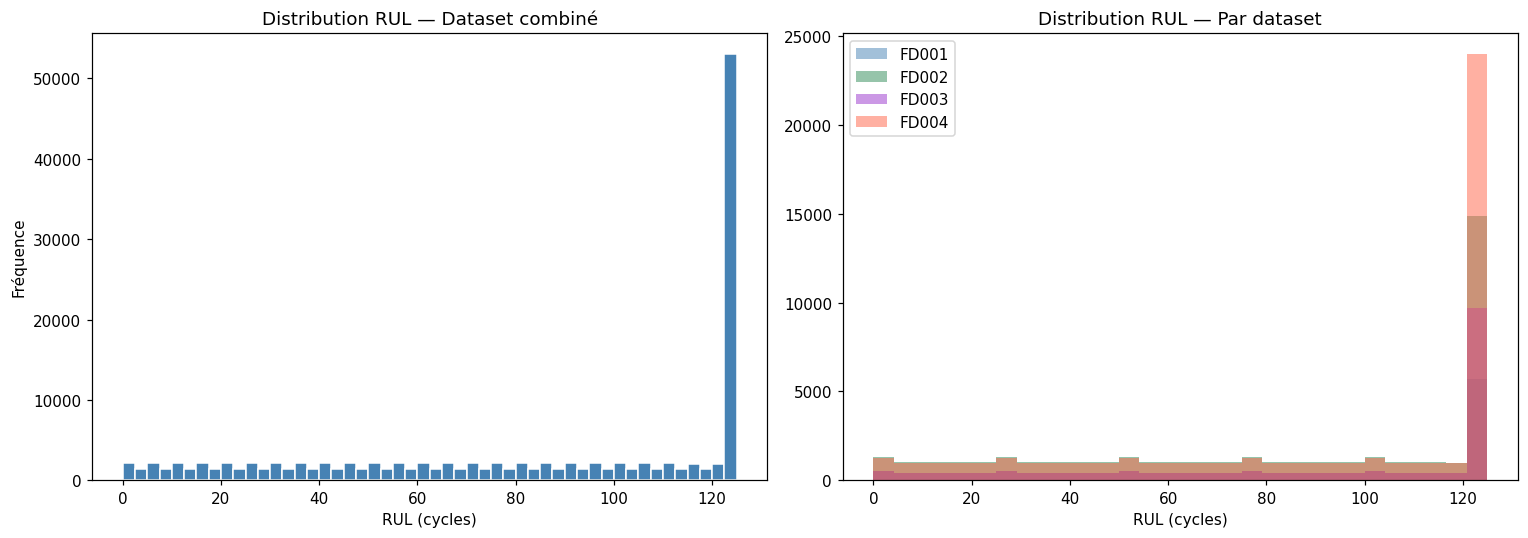

In [9]:
# Distribution RUL dans le dataset combiné
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train_combined, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution RUL — Dataset combiné', fontsize=12)
axes[0].set_xlabel('RUL (cycles)')
axes[0].set_ylabel('Fréquence')

# Par dataset
for y, name, color in [
    (y_train_fd001, 'FD001', 'steelblue'),
    (y_train_fd002, 'FD002', 'seagreen'),
    (y_train_fd003, 'FD003', 'darkorchid'),
    (y_train_fd004, 'FD004', 'tomato'),
]:
    axes[1].hist(y, bins=30, alpha=0.5, label=name, color=color)
axes[1].set_title('Distribution RUL — Par dataset', fontsize=12)
axes[1].set_xlabel('RUL (cycles)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/combined_rul_distribution.png', bbox_inches='tight')
plt.show()

## 8. Sauvegarder tout

In [10]:
# Sauvegarder dataset combiné
np.save(f'{OUTPUT_DIR}/X_train_combined.npy', X_train_combined)
np.save(f'{OUTPUT_DIR}/y_train_combined.npy', y_train_combined)
np.save(f'{OUTPUT_DIR}/unit_ids_combined.npy', unit_ids_combined)

# Config combiné
config_combined = {
    'datasets':       ['FD001', 'FD002', 'FD003', 'FD004'],
    'n_features':     N_FEATURES,
    'feature_cols':   FEATURE_COLS,
    'window_size':    WINDOW_SIZE,
    'rul_cap':        RUL_CAP,
    'normalization':  'per_condition_kmeans',
    'total_sequences': int(X_train_combined.shape[0]),
    'sequences_per_dataset': {
        'FD001': int(X_train_fd001.shape[0]),
        'FD002': int(X_train_fd002.shape[0]),
        'FD003': int(X_train_fd003.shape[0]),
        'FD004': int(X_train_fd004.shape[0]),
    },
    'test_engines': {
        'FD001': int(X_test_fd001.shape[0]),
        'FD002': int(X_test_fd002.shape[0]),
        'FD003': int(X_test_fd003.shape[0]),
        'FD004': int(X_test_fd004.shape[0]),
    }
}

with open(f'{OUTPUT_DIR}/config_combined.json', 'w') as f:
    json.dump(config_combined, f, indent=2)

print('\n Fichiers sauvegardés :')
files = [
    'X_train_combined.npy', 'y_train_combined.npy', 'unit_ids_combined.npy',
    'X_test_fd001.npy', 'y_test_fd001.npy',
    'X_test_fd002.npy', 'y_test_fd002.npy',
    'X_test_fd003.npy', 'y_test_fd003.npy',
    'X_test_fd004.npy', 'y_test_fd004.npy',
    'config_combined.json'
]
for fname in files:
    path = f'{OUTPUT_DIR}/{fname}'
    if os.path.exists(path):
        size = os.path.getsize(path) / (1024*1024)
        print(f'  {fname:35s} → {size:.1f} MB')


 Fichiers sauvegardés :
  X_train_combined.npy                → 272.0 MB
  y_train_combined.npy                → 0.5 MB
  unit_ids_combined.npy               → 1.1 MB
  X_test_fd001.npy                    → 0.2 MB
  y_test_fd001.npy                    → 0.0 MB
  X_test_fd002.npy                    → 0.5 MB
  y_test_fd002.npy                    → 0.0 MB
  X_test_fd003.npy                    → 0.2 MB
  y_test_fd003.npy                    → 0.0 MB
  X_test_fd004.npy                    → 0.5 MB
  y_test_fd004.npy                    → 0.0 MB
  config_combined.json                → 0.0 MB


## 9. Résumé Final

In [11]:
print('=' * 60)
print(' RÉSUMÉ PREPROCESSING COMBINÉ')
print('=' * 60)
print(f'Features          : {N_FEATURES} (14 capteurs + 3 settings)')
print(f'Window size       : {WINDOW_SIZE}')
print(f'RUL cap           : {RUL_CAP}')
print(f'Normalisation     : par condition (KMeans)')
print(f'\nDataset combiné :')
print(f'  X_train shape   : {X_train_combined.shape}')
print(f'  y_train shape   : {y_train_combined.shape}')
print(f'\nTest sets séparés :')
print(f'  FD001 : {X_test_fd001.shape[0]} moteurs')
print(f'  FD002 : {X_test_fd002.shape[0]} moteurs')
print(f'  FD003 : {X_test_fd003.shape[0]} moteurs')
print(f'  FD004 : {X_test_fd004.shape[0]} moteurs')
print('=' * 60)
print(f'\n Preprocessing combiné terminé !')
print(f' Tout dans : {OUTPUT_DIR}')


 RÉSUMÉ PREPROCESSING COMBINÉ
Features          : 17 (14 capteurs + 3 settings)
Window size       : 30
RUL cap           : 125
Normalisation     : par condition (KMeans)

Dataset combiné :
  X_train shape   : (139798, 30, 17)
  y_train shape   : (139798,)

Test sets séparés :
  FD001 : 100 moteurs
  FD002 : 259 moteurs
  FD003 : 100 moteurs
  FD004 : 248 moteurs

 Preprocessing combiné terminé !
 Tout dans : /content/drive/MyDrive/industrial-ai-platform/preprocessing_combined
